# Backend Wrapper

This notebook serves as space for working on the backend wrapper that will connect to the api. Its main body is more apt for a puthon script and so feels slighlty clunky.

In [37]:
from pathlib import Path

import faiss
import numpy as np
import pandas as pd

import sys
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.config.paths import MSD_METADATA_DIR, PROCESSED_DATA_DIR, LMD_MATCHED_DIR, NOTEBOOK_DATASETS_DIR

## Main Code Body

In [38]:


class MusicExplorer:
    """
    Music retrieval and exploration backend.

    Assumptions:
    - metadata has columns: faiss_id, track, artist_name_name_name_name_name_name_name_name_name_name_name
    - embeddings are already StandardScaled + L2 normalised
    - FAISS index was built from embeddings in the same row order
    """

    def __init__(
        self,
        metadata: pd.DataFrame,
        embeddings: np.ndarray,
        index: faiss.Index
    ):
        self.metadata = metadata
        self.embeddings = embeddings
        self.index = index

    @classmethod
    def load(
        cls,
        metadata_path: str | Path,
        embeddings_path: str | Path,
        index_path: str | Path,
    ):
        """
        Load metadata, embeddings and FAISS index from disk.
        """

        metadata_path = Path(metadata_path)
        embeddings_path = Path(embeddings_path)
        index_path = Path(index_path)

        if metadata_path.suffix == ".parquet":
            metadata = pd.read_parquet(metadata_path)
        elif metadata_path.suffix == ".csv":
            metadata = pd.read_csv(metadata_path)
        else:
            raise ValueError(
                "Metadata must be .parquet or .csv"
            )

        embeddings = np.load(embeddings_path)

        index = faiss.read_index(str(index_path))

        return cls(
            metadata=metadata,
            embeddings=embeddings,
            index=index
        )

    def get_song(
        self,
        faiss_id: int
    ) -> dict:
        """
        Return metadata for a song.
        """

        row = self.metadata.loc[
            self.metadata["faiss_id"] == faiss_id
        ]

        if len(row) == 0:
            raise ValueError(
                f"Song ID {faiss_id} not found."
            )

        return row.iloc[0].to_dict()

    def find_song(
        self,
        title_name: str
    ) -> pd.DataFrame:
        """
        Find songs whose title contains title_name.
        """

        matches = self.metadata[
            self.metadata["title"]
            .str.contains(
                title_name,
                case=False,
                na=False
            )
        ]

        return matches

    def get_neighbours(
        self,
        faiss_id: int,
        k: int = 10
    ) -> list[dict]:
        """
        Retrieve k nearest neighbours from FAISS.
        """

        query = self.embeddings[
            faiss_id:faiss_id + 1
        ]

        D, I = self.index.search(
            query,
            k + 1
        )

        results = []

        for idx, score in zip(
            I[0][1:],      # skip self
            D[0][1:]
        ):

            row = self.metadata.iloc[idx]

            results.append(
                {
                    "id": int(idx),
                    "title": row["title"],
                    "artist_name": row["artist_name"],
                    "score": float(score)
                }
            )

        return results

    def search(
        self,
        title_name: str,
        k: int = 10
    ) -> list[dict]:
        """
        Search by title name and return neighbours.
        """

        matches = self.find_song(title_name)

        if len(matches) == 0:
            raise ValueError(
                f"No title found matching '{title_name}'"
            )

        faiss_id = int(
            matches.iloc[0]["faiss_id"]
        )

        return self.get_neighbours(
            faiss_id=faiss_id,
            k=k
        )

    def get_graph(
        self,
        faiss_id: int,
        k: int = 5
    ) -> dict:
        """
        Return a simple graph structure suitable
        for Cytoscape.js / React frontend.
        """

        nodes = []
        edges = []

        center_song = self.get_song(faiss_id)

        nodes.append(
            {
                "id": faiss_id,
                "title": center_song["title"],
                "artist_name": center_song["artist_name"],
                "type": "query"
            }
        )

        neighbours = self.get_neighbours(
            faiss_id=faiss_id,
            k=k
        )

        for neighbour in neighbours:

            nodes.append(
                {
                    "id": neighbour["id"],
                    "title": neighbour["title"],
                    "artist_name": neighbour["artist_name"],
                    "type": "neighbour"
                }
            )

            edges.append(
                {
                    "source": faiss_id,
                    "target": neighbour["id"],
                    "weight": neighbour["score"]
                }
            )

        return {
            "nodes": nodes,
            "edges": edges
        }

    def get_two_hop_graph(
        self,
        faiss_id: int,
        k: int = 5
    ) -> dict:
        """
        Expand neighbourhood to 2 hops.
        Useful for future graph visualisation.
        """

        nodes = {}
        edges = []

        center_song = self.get_song(faiss_id)

        nodes[faiss_id] = {
            "id": faiss_id,
            "title": center_song["title"],
            "artist_name": center_song["artist_name"],
            "type": "query"
        }

        first_hop = self.get_neighbours(
            faiss_id=faiss_id,
            k=k
        )

        for neighbour in first_hop:

            nid = neighbour["id"]

            nodes[nid] = {
                "id": nid,
                "title": neighbour["title"],
                "artist_name": neighbour["artist_name"],
                "type": "hop_1"
            }

            edges.append(
                {
                    "source": faiss_id,
                    "target": nid,
                    "weight": neighbour["score"]
                }
            )

            second_hop = self.get_neighbours(
                faiss_id=nid,
                k=k
            )

            for second in second_hop:

                sid = second["id"]

                if sid not in nodes:

                    nodes[sid] = {
                        "id": sid,
                        "title": second["title"],
                        "artist_name": second["artist_name"],
                        "type": "hop_2"
                    }

                edges.append(
                    {
                        "source": nid,
                        "target": sid,
                        "weight": second["score"]
                    }
                )

        return {
            "nodes": list(nodes.values()),
            "edges": edges
        }


## Testing

In [39]:

metadata = pd.read_csv(f"{PROCESSED_DATA_DIR}/metadata_index.csv")
embeddings = np.load(f"{NOTEBOOK_DATASETS_DIR}/all_features_limit_1000_embeddings.npy")
index = faiss.read_index(f"{NOTEBOOK_DATASETS_DIR}/all_features_limit_1000.index")

In [42]:
metadata.head()

,track_id,artist_name,artist_id,title,song_id,release,genre,midi_path,faiss_id
0,TRAAAGR128F425B14B,Cyndi Lauper,ARGE7G11187FB37E05,Into The Nightlife,SONRWUU12AF72A4283,Bring Ya To The Brink,NaN,C:\Users\danie\Documents\GitHub\music-represen...,0
1,TRAAAZF12903CCCF6B,Matthew Wilder,ARJJ8611187FB5321F,Break My Stride,SOUCVHW12AB018E830,I Don't Speak The Language,NaN,C:\Users\danie\Documents\GitHub\music-represen...,1
2,TRAABVM128F92CA9DC,Tesla,ARYKCQI1187FB3B18F,Caught In A Dream,SOXLBJT12A8C140925,Gold,NaN,C:\Users\danie\Documents\GitHub\music-represen...,2
3,TRAABXH128F42955D6,Brian Wilson,ARD9UVF1187B9B17FE,Keep An Eye On Summer (Album Version),SOHXFBA12A8C13D637,Imagination,NaN,C:\Users\danie\Documents\GitHub\music-represen...,3
4,TRAACQE12903CC706C,Old Man River,ARDDIBO1187B9B0822,Summer,SOGUCAN12AB017BF99,Good Morning,NaN,C:\Users\danie\Documents\GitHub\music-represen...,4


A new ID column is created since song_id is respective to teh million song dataset.

In [40]:
metadata = metadata.reset_index(drop=True)

metadata["faiss_id"] = np.arange(
    len(metadata)
)

In [43]:



explorer = MusicExplorer(
    metadata,
    embeddings,
    index
)

#Search by title
results = explorer.search(
    "Man in the Mirror",
    k=10
)
print(results)

#Graph for frontend
graph = explorer.get_graph(
    faiss_id=1,
    k=5
)
print(graph)

#Two-hop graph
graph_2 = explorer.get_two_hop_graph(
    faiss_id=1,
    k=5
)
print(graph_2)

[{'id': 208, 'title': 'Un Garcon Pas Comme Les Autres (Ziggy)', 'artist_name': 'Céline Dion', 'score': 0.5737673044204712}, {'id': 233, 'title': 'Borealis', 'artist_name': 'DJ Eco', 'score': 0.5713085532188416}, {'id': 788, 'title': 'Bahnsteig', 'artist_name': 'Nadine Norell', 'score': 0.5587574243545532}, {'id': 643, 'title': 'Domino', 'artist_name': 'Kiss', 'score': 0.537179172039032}, {'id': 712, 'title': 'Sexual Healing', 'artist_name': 'Marvin Gaye', 'score': 0.5328057408332825}, {'id': 649, 'title': 'Comme Toi (Live)', 'artist_name': 'Jean-Jacques Goldman', 'score': 0.5314801931381226}, {'id': 516, 'title': 'UnOpened', 'artist_name': 'SONATA ARCTICA', 'score': 0.4907830059528351}, {'id': 427, 'title': 'Rebel Yell (1999 Digital Remaster)', 'artist_name': 'Billy Idol', 'score': 0.46504148840904236}, {'id': 431, 'title': 'Fire (Orange Factory Dub)', 'artist_name': 'Dolce; Orange Factory', 'score': 0.44152817130088806}, {'id': 666, 'title': 'You Make Me Feel Good ', 'artist_name': 'J

## Graph Visualisation

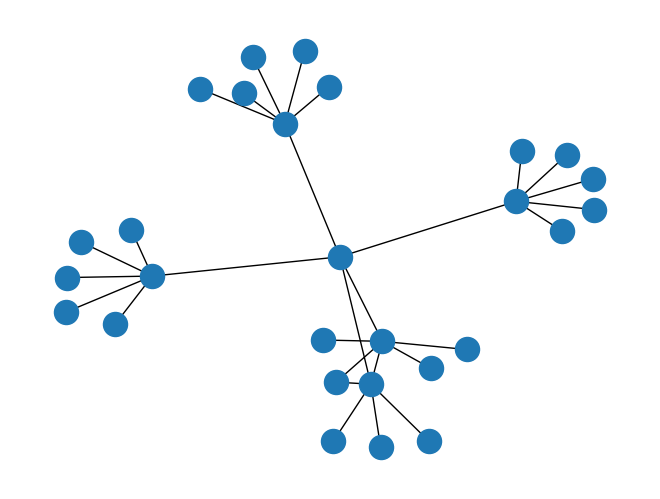

In [45]:
import networkx as nx
import matplotlib.pyplot as plt


G = nx.Graph()

for edge in graph_2["edges"]:
    G.add_edge(
        edge["source"],
        edge["target"],
        weight=edge["weight"]
    )

nx.draw(G)
plt.show()

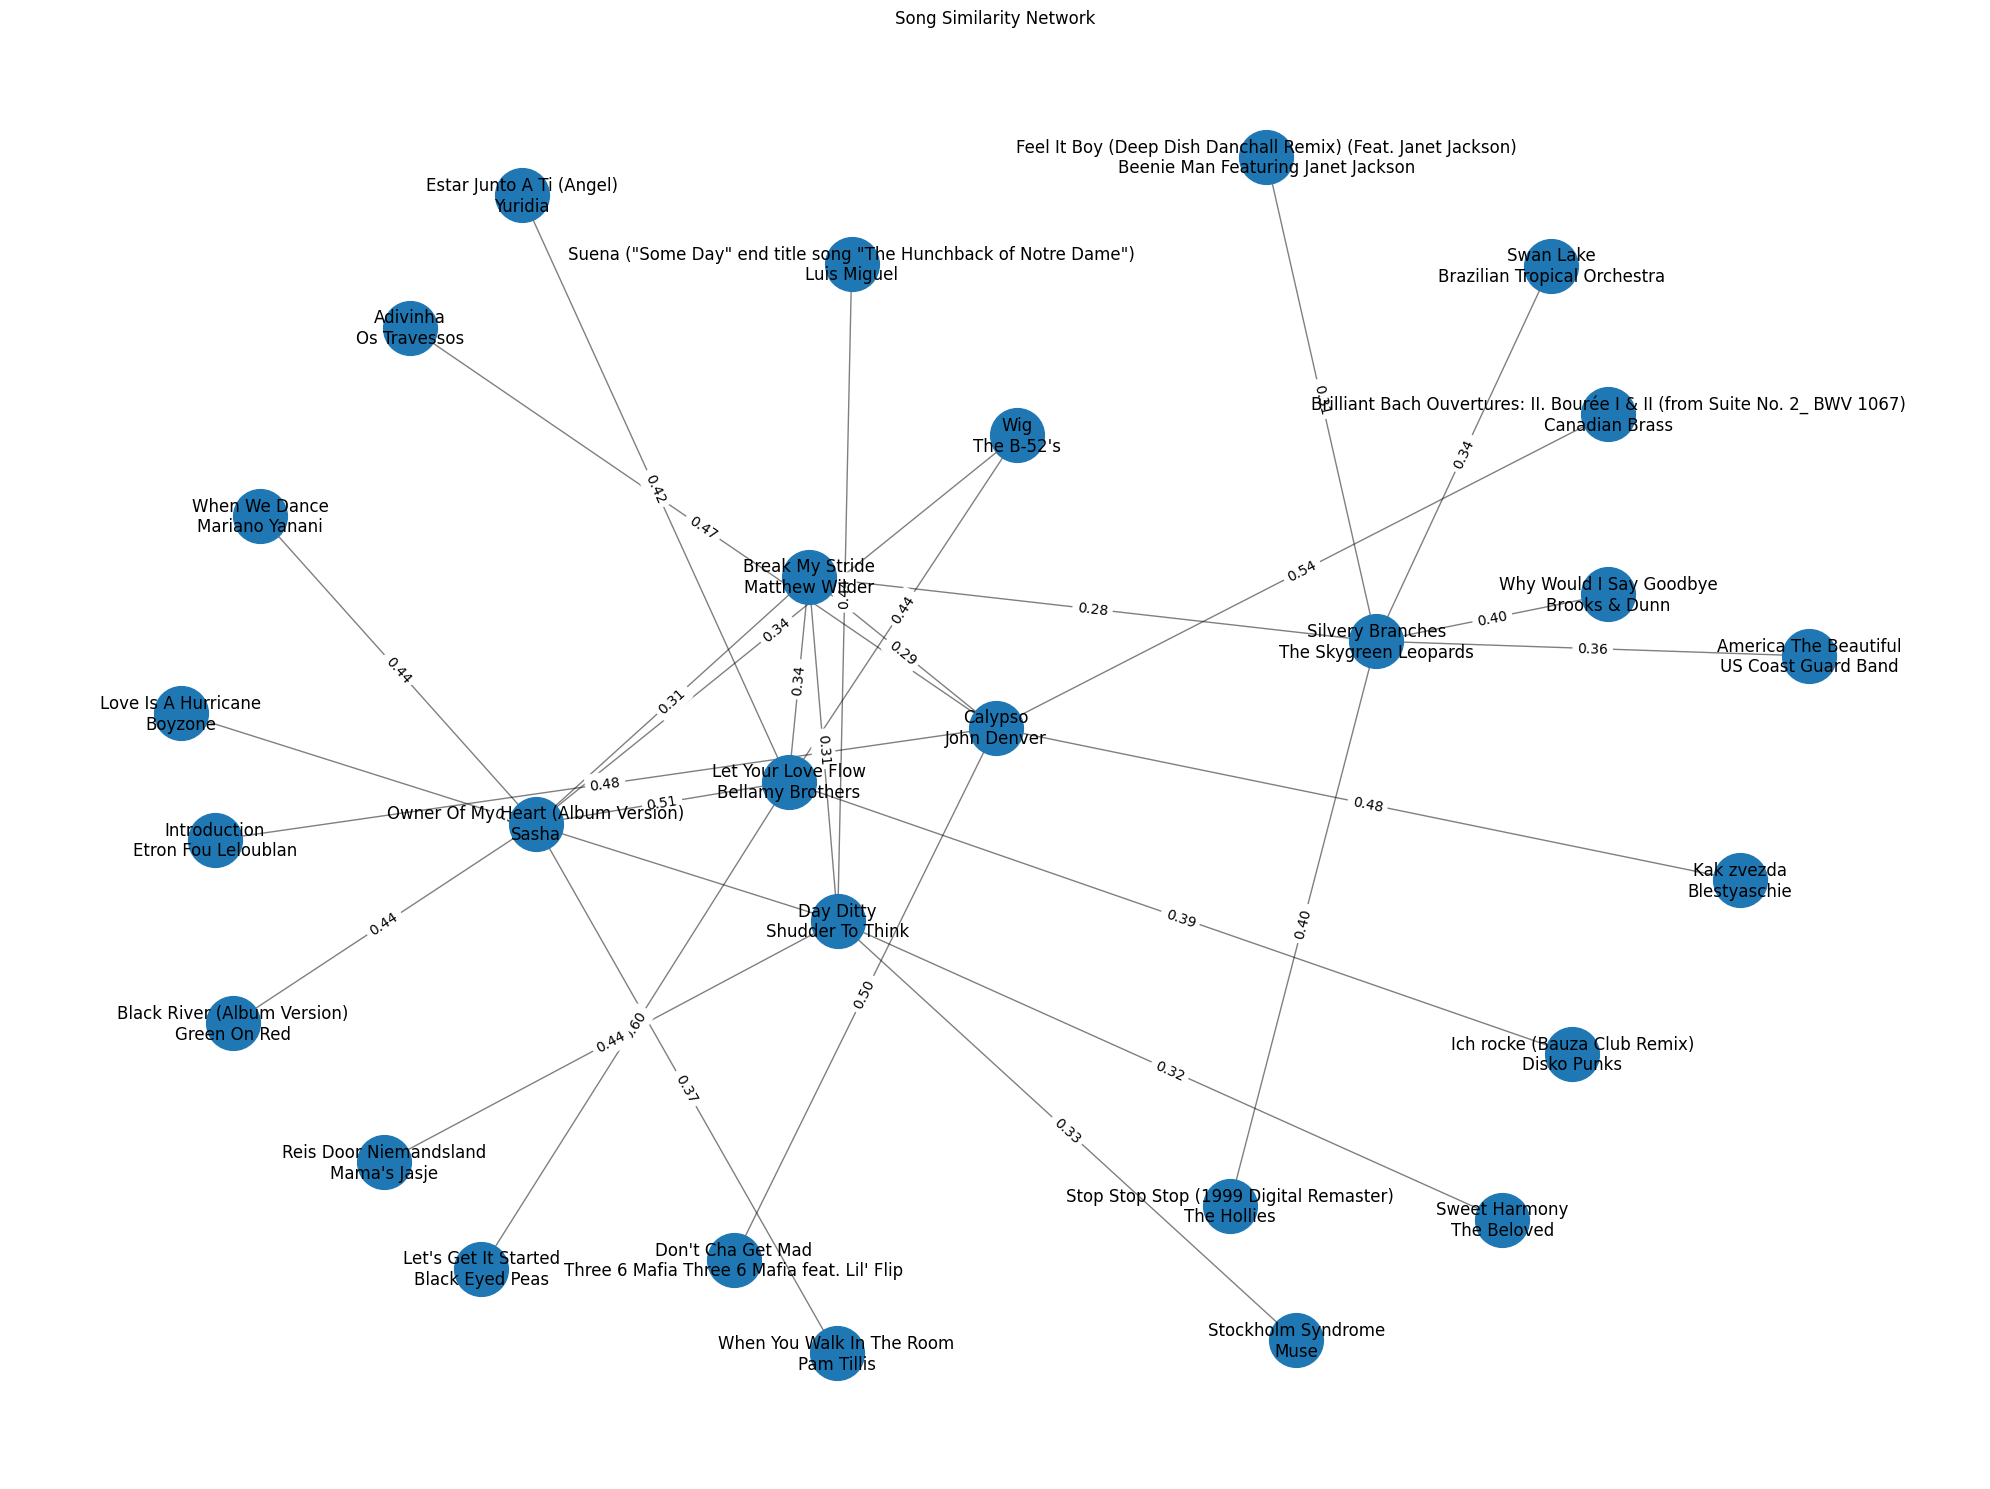

In [54]:
import networkx as nx
import matplotlib.pyplot as plt

# Build graph
G = nx.Graph()

for edge in graph_2["edges"]:
    G.add_edge(
        edge["source"],
        edge["target"],
        weight=edge["weight"]
    )

# Create node labels
node_labels = {}

for node in graph_2["nodes"]:
    node_labels[node["id"]] = (
        f"{node['title']}\n{node['artist_name']}"
    )

# Layout
pos = nx.spring_layout(
    G,
    k=1.5,
    iterations=100,
    seed=42
)

# Draw nodes and edges
plt.figure(figsize=(20, 15))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=1500
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.5
)

# Draw song labels
nx.draw_networkx_labels(
    G,
    pos,
    labels=node_labels,
    font_size=12
)

# Edge weight labels
edge_labels = {
    (u, v): f"{d['weight']:.2f}"
    for u, v, d in G.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=10
)

plt.title("Song Similarity Network")
plt.axis("off")
plt.tight_layout()
plt.show()

## Local PCA/UMAP Explorer

In [50]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

coords = reducer.fit_transform(
    embeddings
)

c:\Users\danie\.venvs\ds\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\danie\.venvs\ds\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
